In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
import matplotlib.pyplot as plt

import os

os.environ["NUMEXPR_MAX_THREADS"] = "8"
os.environ["NUMEXPR_NUM_THREADS"] = "8"

import numpy as np
from pathlib import Path

processed_path = Path("../data/splits/2026-08-16_processed_data_no_duplicates.npz")

data = np.load(processed_path)

print(data.files)

['X_train', 'X_val', 'X_test', 'X_id_train', 'X_id_val', 'X_id_test', 'X_err_train', 'X_err_val', 'X_err_test', 'y_train', 'y_val', 'y_test', 'y_id_train', 'y_id_val', 'y_id_test', 'y_ivar_train', 'y_ivar_val', 'y_ivar_test', 'gaia_wavelength', 'sdss_wavelength']


In [3]:
# Datos de Gaia
X_train = data["X_train"]
X_val = data["X_val"]
X_test = data["X_test"]

# Errores de Gaia
X_err_train = data["X_err_train"]
X_err_val = data["X_err_val"]
X_err_test = data["X_err_test"]

# IDs de Gaia
X_id_train = data["X_id_train"]
X_id_val = data["X_id_val"]
X_id_test = data["X_id_test"]

# Datos de SDSS
y_train = data["y_train"]
y_val = data["y_val"]
y_test = data["y_test"]

# IDs de SDSS
y_id_train = data["y_id_train"]
y_id_val = data["y_id_val"]
y_id_test = data["y_id_test"]

# Longitudes de onda
gaia_wavelength = data["gaia_wavelength"]
sdss_wavelength = data["sdss_wavelength"]

Aplicamos la normalización que mejores resultados dio en la red neuronal densa.

In [4]:
X_scale_train = np.nanmedian(np.abs(X_train), axis=1, keepdims=True)
X_scale_val = np.nanmedian(np.abs(X_val), axis=1, keepdims=True)
X_scale_test = np.nanmedian(np.abs(X_test), axis=1, keepdims=True)

y_scale_train = np.nanmedian(np.abs(y_train), axis=1, keepdims=True)
y_scale_val = np.nanmedian(np.abs(y_val), axis=1, keepdims=True)
y_scale_test = np.nanmedian(np.abs(y_test), axis=1, keepdims=True)

X_train_norm_median_spec = X_train / X_scale_train
X_val_norm_median_spec = X_val / X_scale_val
X_test_norm_median_spec = X_test / X_scale_test

y_train_norm_median_spec = y_train / y_scale_train
y_val_norm_median_spec = y_val / y_scale_val
y_test_norm_median_spec = y_test / y_scale_test

Preparamos los datos para la RNN añadiendo una tercera dimensión para las variables por cada paso (punto de la longitud de onda).

In [5]:
X_train_rnn = X_train_norm_median_spec[..., np.newaxis]
X_val_rnn = X_val_norm_median_spec[..., np.newaxis]
X_test_rnn = X_test_norm_median_spec[..., np.newaxis]

print("X_train_rnn:", X_train_rnn.shape)
print("X_val_rnn:", X_val_rnn.shape)
print("X_test_rnn:", X_test_rnn.shape)

X_train_rnn: (32656, 201, 1)
X_val_rnn: (4082, 201, 1)
X_test_rnn: (4082, 201, 1)


Definimos un primer modelo base para hacer pruebas.

In [5]:
n_gaia = X_train_rnn.shape[1]
n_features = X_train_rnn.shape[2]
n_sdss = y_train_norm_median_spec.shape[1]

model_rnn = models.Sequential([
    layers.Input(shape=(n_gaia, n_features)),

    layers.GRU(128, return_sequences=True),

    layers.GRU(128, return_sequences=False),

    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(n_sdss)
])

model_rnn.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm=1.0),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 201, 128)       │        50,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,473,386 (13.25 MB)

 Trainable params: 3,473,386 (13.25 MB)

 Non-trainable params: 0 (0.00 B)

Definimos las mismas funciones que en el caso denso. 

In [27]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    min_delta=1e-4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

Ejecutamos el entrenamiento del modelo.

In [7]:
history_rnn = model_rnn.fit(
    X_train_rnn,
    y_train_norm_median_spec,
    validation_data=(X_val_rnn, y_val_norm_median_spec),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 240s 460ms/step - loss: 0.1882 - mae: 0.4437 - mse: 0.4169 - val_loss: 0.0108 - val_mae: 0.0800 - val_mse: 0.0316 - learning_rate: 1.0000e-04
Epoch 2/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 222s 434ms/step - loss: 0.0095 - mae: 0.0732 - mse: 0.0254 - val_loss: 0.0075 - val_mae: 0.0628 - val_mse: 0.0219 - learning_rate: 1.0000e-04
Epoch 3/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 228s 445ms/step - loss: 0.0074 - mae: 0.0639 - mse: 0.0191 - val_loss: 0.0068 - val_mae: 0.0598 - val_mse: 0.0191 - learning_rate: 1.0000e-04
Epoch 4/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 220s 431ms/step - loss: 0.0065 - mae: 0.0607 - mse: 0.0164 - val_loss: 0.0069 - val_mae: 0.0669 - val_mse: 0.0189 - learning_rate: 1.0000e-04
Epoch 5/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 220s 431ms/step - loss: 0.0057 - mae: 0.0566 - mse: 0.0145 - val_loss: 0.0051 - val_mae: 0.0523 - val_mse: 0.0152 - learning_rate: 1.0000e-04
Epoch 6/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 221s 433ms/step - loss: 0.0050 - mae: 0.0533 - mse

In [8]:
test_results_rnn = model_rnn.evaluate(
    X_test_rnn,
    y_test_norm_median_spec,
    verbose=1
)

128/128 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - loss: 0.0045 - mae: 0.0490 - mse: 0.0124


In [ ]:
model_simple_rnn = models.Sequential([
    layers.Input(shape=(n_gaia, n_features)),

    # RNN básica
    layers.SimpleRNN(128, return_sequences=False),

    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(n_sdss)
])

model_simple_rnn.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm=1.0),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_simple_rnn.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_18 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_19 (LeakyReLU)      │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,439,850 (20.75 MB)

 Trainable params: 5,439,850 (20.75 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
history_simple_rnn = model_simple_rnn.fit(
    X_train_rnn,
    y_train_norm_median_spec,
    validation_data=(X_val_rnn, y_val_norm_median_spec),
    epochs=25,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 42s 70ms/step - loss: 0.0893 - mae: 0.2515 - mse: 0.2052 - val_loss: 0.0073 - val_mae: 0.0654 - val_mse: 0.0201 - learning_rate: 1.0000e-04
Epoch 2/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 38s 74ms/step - loss: 0.0073 - mae: 0.0656 - mse: 0.0172 - val_loss: 0.0068 - val_mae: 0.0627 - val_mse: 0.0187 - learning_rate: 1.0000e-04
Epoch 3/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 71s 138ms/step - loss: 0.0070 - mae: 0.0638 - mse: 0.0174 - val_loss: 0.0067 - val_mae: 0.0644 - val_mse: 0.0185 - learning_rate: 1.0000e-04
Epoch 4/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 57s 111ms/step - loss: 0.0067 - mae: 0.0628 - mse: 0.0166 - val_loss: 0.0065 - val_mae: 0.0612 - val_mse: 0.0180 - learning_rate: 1.0000e-04
Epoch 5/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 55s 107ms/step - loss: 0.0068 - mae: 0.0637 - mse: 0.0163 - val_loss: 0.0075 - val_mae: 0.0698 - val_mse: 0.0200 - learning_rate: 1.0000e-04
Epoch 6/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.0066 - mae: 0.0627 - mse: 0.0163


In [48]:
test_results_rnn_simple = model_simple_rnn.evaluate(
    X_test_rnn,
    y_test_norm_median_spec,
    verbose=1
)

128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0054 - mae: 0.0542 - mse: 0.0141


In [28]:
model_rnn_small = models.Sequential([
    layers.Input(shape=(n_gaia, n_features)),

    layers.GRU(128, return_sequences=False),

    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(n_sdss)
])

model_rnn_small.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm=1.0),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_rnn_small.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_5 (GRU)                     │ (None, 128)            │        50,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,374,314 (12.87 MB)

 Trainable params: 3,374,314 (12.87 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history_rnn_small = model_rnn_small.fit(
    X_train_rnn,
    y_train_norm_median_spec,
    validation_data=(X_val_rnn, y_val_norm_median_spec),
    epochs=25,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 66s 126ms/step - loss: 0.2013 - mae: 0.4692 - mse: 0.4448 - val_loss: 0.0116 - val_mae: 0.0866 - val_mse: 0.0309 - learning_rate: 1.0000e-04
Epoch 2/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 63s 123ms/step - loss: 0.0103 - mae: 0.0791 - mse: 0.0256 - val_loss: 0.0087 - val_mae: 0.0756 - val_mse: 0.0239 - learning_rate: 1.0000e-04
Epoch 3/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 63s 124ms/step - loss: 0.0079 - mae: 0.0666 - mse: 0.0205 - val_loss: 0.0073 - val_mae: 0.0638 - val_mse: 0.0202 - learning_rate: 1.0000e-04
Epoch 4/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 63s 123ms/step - loss: 0.0072 - mae: 0.0636 - mse: 0.0177 - val_loss: 0.0079 - val_mae: 0.0682 - val_mse: 0.0211 - learning_rate: 1.0000e-04
Epoch 5/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 63s 123ms/step - loss: 0.0069 - mae: 0.0629 - mse: 0.0171 - val_loss: 0.0068 - val_mae: 0.0615 - val_mse: 0.0188 - learning_rate: 1.0000e-04
Epoch 6/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 62s 120ms/step - loss: 0.0067 - mae: 0.0611 - mse: 0.01

In [30]:
test_results_small_rnn = model_rnn_small.evaluate(
    X_test_rnn,
    y_test_norm_median_spec,
    verbose=1
)

128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.0045 - mae: 0.0486 - mse: 0.0123


In [31]:
y_pred_norm_small= model_rnn_small.predict(X_test_norm_median_spec)
y_pred_spec_small = y_pred_norm_small* y_scale_test

128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step


In [61]:
import sys
from pathlib import Path

ISPEC_FUNCTIONS_DIR = Path(
    "../solution/models"
)

if str(ISPEC_FUNCTIONS_DIR) not in sys.path:
    sys.path.insert(0, str(ISPEC_FUNCTIONS_DIR))

# Importamos Funciones iSpec
from iSpec_functions import (
    load_ispec_resources,
    analyze_sample_real_vs_pred,
    analyze_ispec_errors
)
# Recargamos si ha habido modificaciones
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

# Cargamos Resources
resources = load_ispec_resources()

from astropy.table import Table
# Cargamos la tabla de Gaia guardada en local
gaia_data_path = Path("../data/gaia_data.ecsv")

gaia_data_table = Table.read(
    gaia_data_path,
    format="ascii.ecsv"
)

# Pasamos a dataframe
gaia_data_df = gaia_data_table.to_pandas()



Recursos de iSpec cargados correctamente.


In [63]:
# Recargamos si ha habido modificaciones
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
results_df_small = analyze_sample_real_vs_pred(   
    y_test,
    y_pred_spec_small,
    X_id_test,
    gaia_data_df,
    sdss_wavelength,
    resources,
    sample_size=250
)

Espectros analizados:   0%|          | 0/250 [00:00<?, ?cuerpos estelares/s]

Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE




Only LTE




Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE

[2026-08-27 01:26:12,604] [WARNING] [atmospheres:_interpolate:114]: Target point '3500.0 2.6911155921887264 -4.559396401646393 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-08-27 01:26:15,648] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.
[2026-08-27 01:26:27,690] [WARNING] [atmospheres:_interpolate:114]: Target point '3500.0 2.9241712653553704 -4.433403594384137 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-08-27 01:26:30,718] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.
[2026-08-27 01:26:42,713] [WARNING] [atmospheres:_interpolate:114]: Target point '3538.718101860612 2.1204109244531257 -4.114757058193999 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-2
. . . now exiting to system . . .
[2026-08-2

Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE

[2026-08-27 03:04:14,081] [WARNING] [atmospheres:_interpolate:114]: Target point '6894.391128764864 4.401123225545442 -5.5 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-08-27 03:04:17,110] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.


Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE


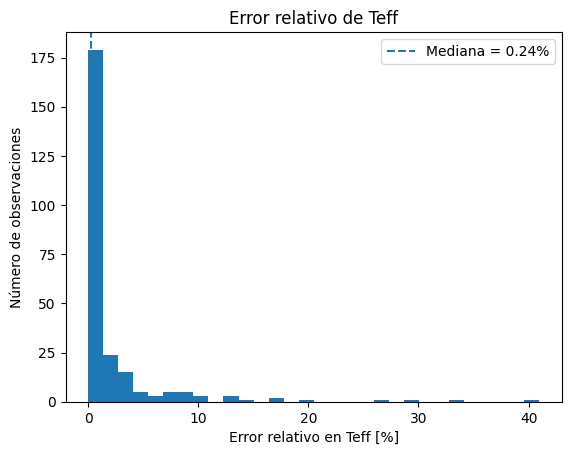

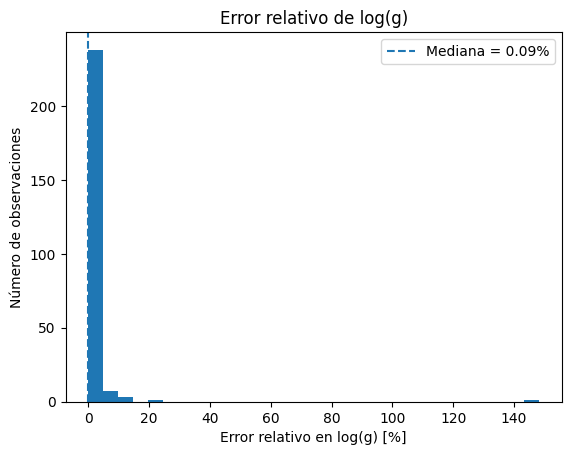

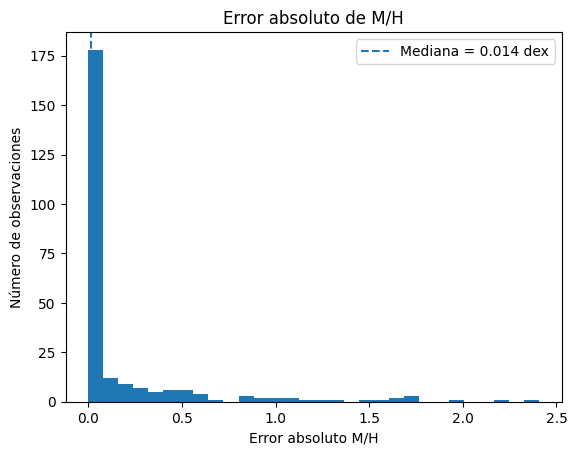

In [33]:
error_df_small = analyze_ispec_errors(results_df_small)

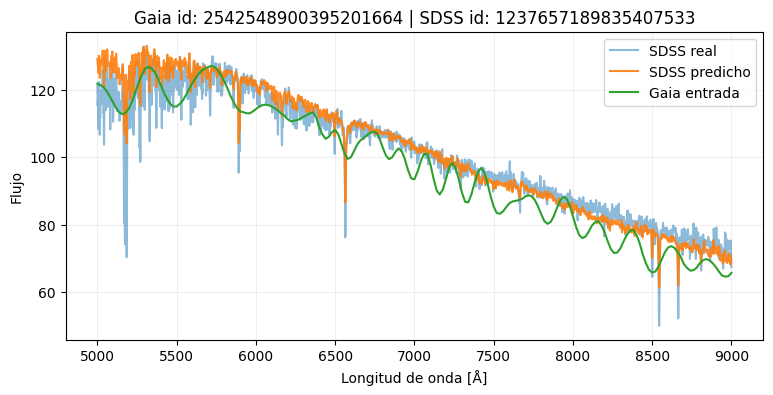

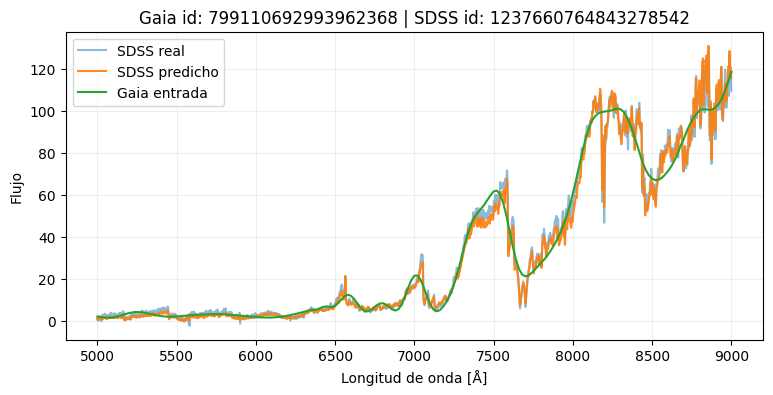

In [39]:
# Importamos funciones a usar para analizar resultados
from model_functions import (
    plot_training_metrics,
    plot_prediction_example,
    plot_worst_best_predictions
)

plot_prediction_example(
    245,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_spec_small,
    y_id_test,
    X_test,
    X_id_test
)

plot_prediction_example(
    10,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_spec_small,
    y_id_test,
    X_test,
    X_id_test
)

In [12]:
model_rnn_small_2 = models.Sequential([
    layers.Input(shape=(n_gaia, n_features)),

    layers.GRU(128, return_sequences=False),

    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(n_sdss)
])

model_rnn_small_2.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm=1.0),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_rnn_small_2.summary()

history_rnn_small_2 = model_rnn_small_2.fit(
    X_train_rnn,
    y_train_norm_median_spec,
    validation_data=(X_val_rnn, y_val_norm_median_spec),
    epochs=25,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_3 (GRU)                     │ (None, 128)            │        50,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,374,314 (12.87 MB)

 Trainable params: 3,374,314 (12.87 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 92s 178ms/step - loss: 0.2029 - mae: 0.4736 - mse: 0.4488 - val_loss: 0.0116 - val_mae: 0.0830 - val_mse: 0.0316 - learning_rate: 1.0000e-04
Epoch 2/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 89s 173ms/step - loss: 0.0106 - mae: 0.0799 - mse: 0.0273 - val_loss: 0.0089 - val_mae: 0.0762 - val_mse: 0.0251 - learning_rate: 1.0000e-04
Epoch 3/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 86s 168ms/step - loss: 0.0080 - mae: 0.0672 - mse: 0.0201 - val_loss: 0.0083 - val_mae: 0.0742 - val_mse: 0.0226 - learning_rate: 1.0000e-04
Epoch 4/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 87s 170ms/step - loss: 0.0074 - mae: 0.0649 - mse: 0.0184 - val_loss: 0.0083 - val_mae: 0.0769 - val_mse: 0.0219 - learning_rate: 1.0000e-04
Epoch 5/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 99s 193ms/step - loss: 0.0070 - mae: 0.0628 - mse: 0.0172 - val_loss: 0.0074 - val_mae: 0.0657 - val_mse: 0.0199 - learning_rate: 1.0000e-04
Epoch 6/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 91s 177ms/step - loss: 0.0067 - mae: 0.0615 - mse: 0.01

In [49]:
test_results_rnn_small_2 = model_rnn_small_2.evaluate(
    X_test_rnn,
    y_test_norm_median_spec,
    verbose=1
)

128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.0046 - mae: 0.0490 - mse: 0.0125


In [13]:
model_rnn_small_3 = models.Sequential([
    layers.Input(shape=(n_gaia, n_features)),

    layers.GRU(128, return_sequences=False),
    layers.LayerNormalization(),

    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(n_sdss)
])

model_rnn_small_3.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm=1.0),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_rnn_small_3.summary()

history_rnn_small_3 = model_rnn_small_3.fit(
    X_train_rnn,
    y_train_norm_median_spec,
    validation_data=(X_val_rnn, y_val_norm_median_spec),
    epochs=25,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_4 (GRU)                     │ (None, 128)            │        50,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 128)            │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,374,570 (12.87 MB)

 Trainable params: 3,374,570 (12.87 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 88s 169ms/step - loss: 0.1144 - mae: 0.3096 - mse: 0.2674 - val_loss: 0.0099 - val_mae: 0.0720 - val_mse: 0.0293 - learning_rate: 1.0000e-04
Epoch 2/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 88s 172ms/step - loss: 0.0091 - mae: 0.0693 - mse: 0.0240 - val_loss: 0.0077 - val_mae: 0.0662 - val_mse: 0.0214 - learning_rate: 1.0000e-04
Epoch 3/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 128s 251ms/step - loss: 0.0073 - mae: 0.0637 - mse: 0.0180 - val_loss: 0.0071 - val_mae: 0.0667 - val_mse: 0.0194 - learning_rate: 1.0000e-04
Epoch 4/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 113s 221ms/step - loss: 0.0067 - mae: 0.0616 - mse: 0.0162 - val_loss: 0.0066 - val_mae: 0.0603 - val_mse: 0.0182 - learning_rate: 1.0000e-04
Epoch 5/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 105s 206ms/step - loss: 0.0065 - mae: 0.0613 - mse: 0.0159 - val_loss: 0.0067 - val_mae: 0.0630 - val_mse: 0.0185 - learning_rate: 1.0000e-04
Epoch 6/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - loss: 0.0064 - mae: 0.0606 - mse: 0.

In [50]:
test_results_rnn_small_3 = model_rnn_small_3.evaluate(
    X_test_rnn,
    y_test_norm_median_spec,
    verbose=1
)

128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.0044 - mae: 0.0487 - mse: 0.0123


In [14]:
model_rnn_small_4 = models.Sequential([
    layers.Input(shape=(n_gaia, n_features)),

    layers.GRU(64, return_sequences=True),
    layers.GRU(64, return_sequences=False),

    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(n_sdss)
])

model_rnn_small_4.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm=1.0),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_rnn_small_4.summary()

history_rnn_small_4 = model_rnn_small_4.fit(
    X_train_rnn,
    y_train_norm_median_spec,
    validation_data=(X_val_rnn, y_val_norm_median_spec),
    epochs=25,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_5 (GRU)                     │ (None, 201, 64)        │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_6 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │        33,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329,066 (12.70 MB)

 Trainable params: 3,329,066 (12.70 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 81s 155ms/step - loss: 0.2115 - mae: 0.4877 - mse: 0.4692 - val_loss: 0.0121 - val_mae: 0.0880 - val_mse: 0.0339 - learning_rate: 1.0000e-04
Epoch 2/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 78s 152ms/step - loss: 0.0109 - mae: 0.0804 - mse: 0.0278 - val_loss: 0.0085 - val_mae: 0.0671 - val_mse: 0.0243 - learning_rate: 1.0000e-04
Epoch 3/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 79s 154ms/step - loss: 0.0081 - mae: 0.0664 - mse: 0.0203 - val_loss: 0.0078 - val_mae: 0.0641 - val_mse: 0.0217 - learning_rate: 1.0000e-04
Epoch 4/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 77s 150ms/step - loss: 0.0075 - mae: 0.0637 - mse: 0.0190 - val_loss: 0.0069 - val_mae: 0.0598 - val_mse: 0.0192 - learning_rate: 1.0000e-04
Epoch 5/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 75s 147ms/step - loss: 0.0068 - mae: 0.0609 - mse: 0.0165 - val_loss: 0.0066 - val_mae: 0.0595 - val_mse: 0.0183 - learning_rate: 1.0000e-04
Epoch 6/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 77s 150ms/step - loss: 0.0065 - mae: 0.0601 - mse: 0.01

In [51]:
test_results_rnn_small_4 = model_rnn_small_4.evaluate(
    X_test_rnn,
    y_test_norm_median_spec,
    verbose=1
)

128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.0063 - mae: 0.0587 - mse: 0.0160


In [15]:
model_rnn_5 = models.Sequential([
    layers.Input(shape=(n_gaia, n_features)),

    layers.GRU(128, return_sequences=True),
    layers.GRU(128, return_sequences=False),

    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(n_sdss)
])

model_rnn_5.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm=1.0),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_rnn_5.summary()

history_rnn_5 = model_rnn_5.fit(
    X_train_rnn,
    y_train_norm_median_spec,
    validation_data=(X_val_rnn, y_val_norm_median_spec),
    epochs=25,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_7 (GRU)                     │ (None, 201, 128)       │        50,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_8 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,572,586 (21.26 MB)

 Trainable params: 5,572,586 (21.26 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 189s 366ms/step - loss: 0.1382 - mae: 0.3510 - mse: 0.3046 - val_loss: 0.0153 - val_mae: 0.1061 - val_mse: 0.0403 - learning_rate: 1.0000e-04
Epoch 2/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 173s 338ms/step - loss: 0.0130 - mae: 0.0905 - mse: 0.0322 - val_loss: 0.0097 - val_mae: 0.0810 - val_mse: 0.0263 - learning_rate: 1.0000e-04
Epoch 3/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 178s 349ms/step - loss: 0.0087 - mae: 0.0727 - mse: 0.0214 - val_loss: 0.0077 - val_mae: 0.0683 - val_mse: 0.0210 - learning_rate: 1.0000e-04
Epoch 4/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 182s 356ms/step - loss: 0.0072 - mae: 0.0661 - mse: 0.0183 - val_loss: 0.0063 - val_mae: 0.0624 - val_mse: 0.0177 - learning_rate: 1.0000e-04
Epoch 5/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 179s 351ms/step - loss: 0.0063 - mae: 0.0621 - mse: 0.0149 - val_loss: 0.0057 - val_mae: 0.0582 - val_mse: 0.0164 - learning_rate: 1.0000e-04
Epoch 6/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 183s 359ms/step - loss: 0.0057 - mae: 0.0598 - mse

In [16]:
y_pred_norm= model_rnn_5.predict(X_test_norm_median_spec)
y_pred_spec = y_pred_norm* y_scale_test

128/128 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step


In [53]:
test_results_rnn_5 = model_rnn_5.evaluate(
    X_test_rnn,
    y_test_norm_median_spec,
    verbose=1
)

128/128 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - loss: 0.0045 - mae: 0.0490 - mse: 0.0124


In [6]:
import sys
from pathlib import Path

ISPEC_FUNCTIONS_DIR = Path(
    "../solution/models"
)

if str(ISPEC_FUNCTIONS_DIR) not in sys.path:
    sys.path.insert(0, str(ISPEC_FUNCTIONS_DIR))

In [7]:
# Importamos Funciones iSpec
from iSpec_functions import (
    load_ispec_resources,
    analyze_sample_real_vs_pred,
    analyze_ispec_errors
)

In [8]:
# Cargamos Resources
resources = load_ispec_resources()


Recursos de iSpec cargados correctamente.


In [9]:
from astropy.table import Table
# Cargamos la tabla de Gaia guardada en local
gaia_data_path = Path("../data/gaia_data.ecsv")

gaia_data_table = Table.read(
    gaia_data_path,
    format="ascii.ecsv"
)

# Pasamos a dataframe
gaia_data_df = gaia_data_table.to_pandas()

In [23]:
# Analizamos y devolvemos DF con valores ajustados a los espectros
results_df_rnn = analyze_sample_real_vs_pred(   
    y_test,
    y_pred_spec,
    X_id_test,
    gaia_data_df,
    sdss_wavelength,
    resources,
    sample_size=300
)

Espectros analizados:   0%|          | 0/300 [00:00<?, ?cuerpos estelares/s]

Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE


[2026-08-20 22:40:13,408] [WARNING] [atmospheres:_interpolate:114]: Target point '4642.083931059987 5.5 -0.6693910997863578' is out of bound, using the closest
[2026-08-20 22:41:15,295] [WARNING] [atmospheres:_interpolate:114]: Target point '4941.116963000216 5.420738682721558 -0.43848983890650706' is out of bound, using the closest
[2026-08-20 22:41:39,257] [WARNING] [atmospheres:_interpolate:114]: Target point '5006.222906645974 5.413800000424778 -0.42792597394714504' is out of bound, using the closest


Only LTE


[2026-08-20 22:42:08,405] [WARNING] [atmospheres:_interpolate:114]: Target point '4697.903642782216 5.5 -0.661228000417418' is out of bound, using the closest


...

Only LTE
Only LTE
Only LTE
Only LTE
Only LTE


[2026-08-21 07:03:57,473] [WARNING] [atmospheres:_interpolate:114]: Target point '4031.7701301480015 5.5 -1.1914202085137093' is out of bound, using the closest


Only LTE


[2026-08-21 07:05:37,832] [WARNING] [atmospheres:_interpolate:114]: Target point '3909.244276472078 5.5 -1.3429413713619724' is out of bound, using the closest
[2026-08-21 07:06:36,677] [WARNING] [atmospheres:_interpolate:114]: Target point '4199.513567617087 5.5 -1.8313934475390257' is out of bound, using the closest


Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE


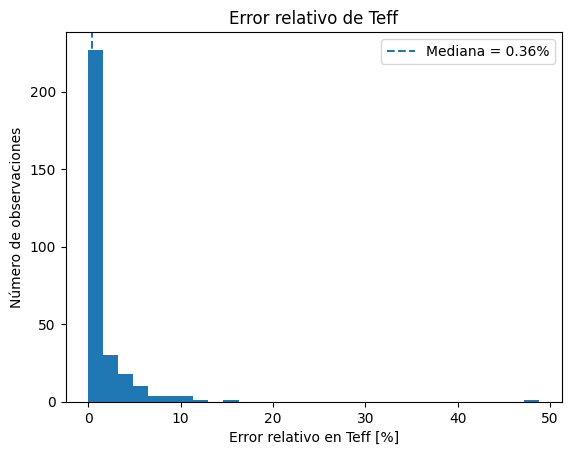

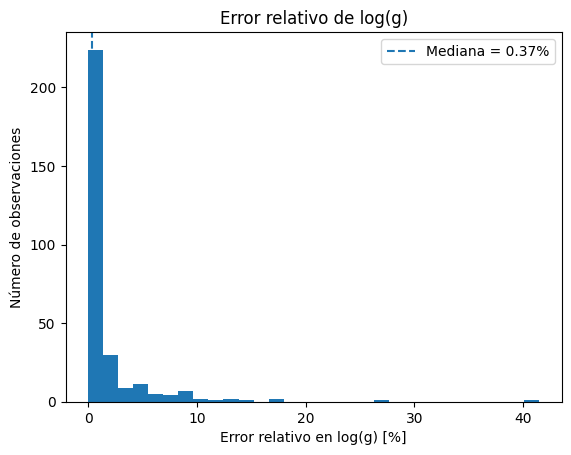

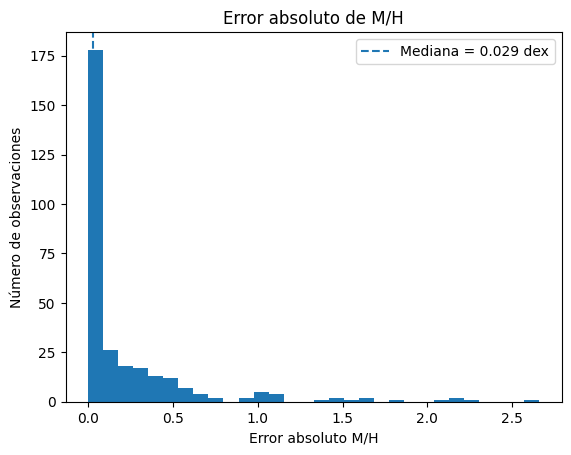

In [24]:
error_df_rnn = analyze_ispec_errors(results_df_rnn)

In [20]:
class AttentionPooling(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.attention_dense = layers.Dense(1)
        super().build(input_shape)

    def call(self, inputs):
        scores = self.attention_dense(inputs)
        weights = tf.nn.softmax(scores, axis=1)
        context = tf.reduce_sum(inputs * weights, axis=1)
        return context

In [29]:
inputs = layers.Input(shape=(n_gaia, n_features))

x = layers.Bidirectional(layers.GRU(128,return_sequences=True))(inputs)
x = layers.LayerNormalization()(x)
x = layers.Bidirectional(layers.GRU(64,return_sequences=True))(x)
x = layers.LayerNormalization()(x)

# Aplicamos Atención sobre todos los puntos del espectro
x = AttentionPooling()(x)

# Parte densa que ya hemos comprobado que funciona bien
x = layers.Dense(512)(x)
x = layers.LeakyReLU(negative_slope=0.01)(x)

x = layers.Dense(1024, activation="elu")(x)

x = layers.Dense(1024)(x)
x = layers.LeakyReLU(negative_slope=0.01)(x)

x = layers.Dense(1024, activation="elu")(x)

outputs = layers.Dense(n_sdss)(x)

model_birnn_attention = models.Model(inputs, outputs)

model_birnn_attention.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm=1.0),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_birnn_attention.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 201, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 201, 256)       │       100,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_3           │ (None, 201, 256)       │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 201, 128)       │       123,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_4           │ (None, 201, 128)       │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_pooling_1             │ (None, 128)            │           129 │
│ (AttentionPooling)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_14 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_15 (LeakyReLU)      │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,648,363 (21.55 MB)

 Trainable params: 5,648,363 (21.55 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
early_stop_earlier = EarlyStopping(
    monitor="val_loss",
    patience=2,
    min_delta=1e-4,
    restore_best_weights=True
)

reduce_lr_earlier = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-6,
    verbose=1
)

history_birnn_attention = model_birnn_attention.fit(
    X_train_rnn,
    y_train_norm_median_spec,
    validation_data=(X_val_rnn, y_val_norm_median_spec),
    epochs=15,
    batch_size=64,
    callbacks=[early_stop_earlier, reduce_lr_earlier],
    verbose=1
)

Epoch 1/15
511/511 ━━━━━━━━━━━━━━━━━━━━ 416s 797ms/step - loss: 0.0934 - mae: 0.2772 - mse: 0.2174 - val_loss: 0.0058 - val_mae: 0.0613 - val_mse: 0.0177 - learning_rate: 1.0000e-04
Epoch 2/15
511/511 ━━━━━━━━━━━━━━━━━━━━ 392s 768ms/step - loss: 0.0054 - mae: 0.0576 - mse: 0.0142 - val_loss: 0.0050 - val_mae: 0.0540 - val_mse: 0.0153 - learning_rate: 1.0000e-04
Epoch 3/15
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 721ms/step - loss: 0.0047 - mae: 0.0530 - mse: 0.0116
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
511/511 ━━━━━━━━━━━━━━━━━━━━ 383s 749ms/step - loss: 0.0047 - mae: 0.0530 - mse: 0.0116 - val_loss: 0.0054 - val_mae: 0.0649 - val_mse: 0.0158 - learning_rate: 1.0000e-04
Epoch 4/15
511/511 ━━━━━━━━━━━━━━━━━━━━ 373s 729ms/step - loss: 0.0046 - mae: 0.0516 - mse: 0.0115 - val_loss: 0.0049 - val_mae: 0.0539 - val_mse: 0.0148 - learning_rate: 5.0000e-05
Epoch 5/15
511/511 ━━━━━━━━━━━━━━━━━━━━ 355s 694ms/step - loss: 0.0047 - mae: 0.0512 - mse: 0.0129 - val_loss:

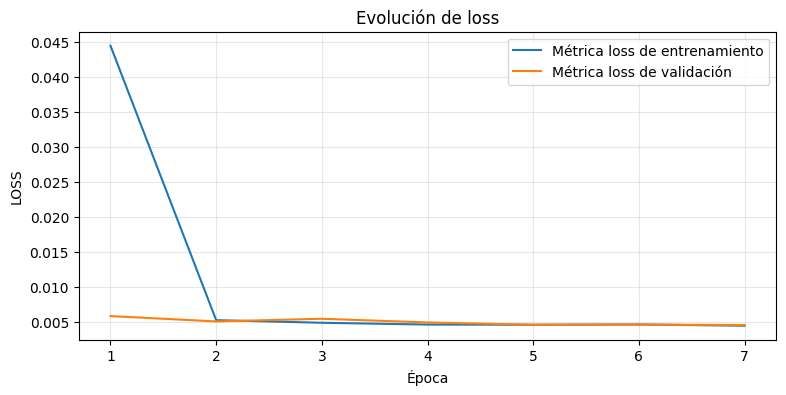

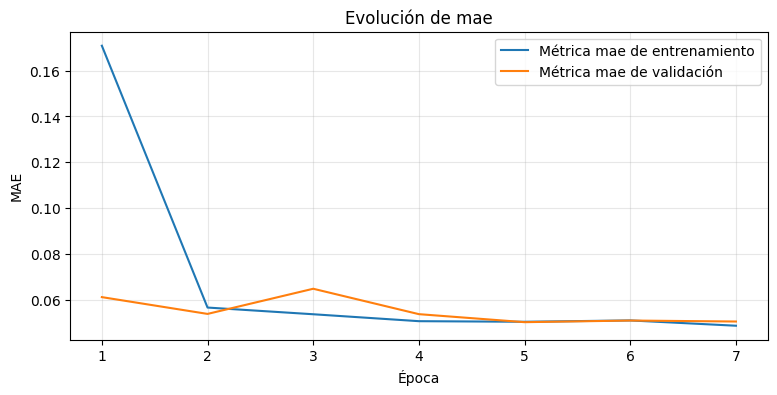

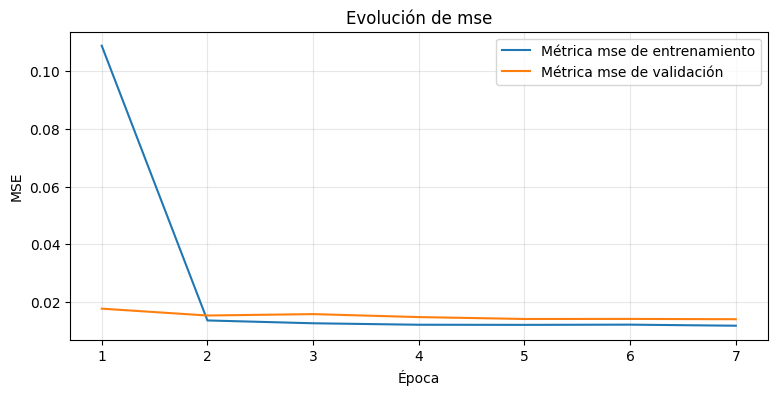

128/128 ━━━━━━━━━━━━━━━━━━━━ 28s 198ms/step


In [31]:
# Importamos funciones a usar para analizar resultados
from model_functions import (
    plot_training_metrics,
    plot_prediction_example,
    plot_worst_best_predictions
)

model_data_birnn_attention = history_birnn_attention.history
plot_training_metrics(model_data_birnn_attention)

# Predecimos sobre el conjunto de test
y_pred_birnn_attention_norm = model_birnn_attention.predict(X_test_rnn)
y_pred_birnn_attention = y_pred_birnn_attention_norm * y_scale_test

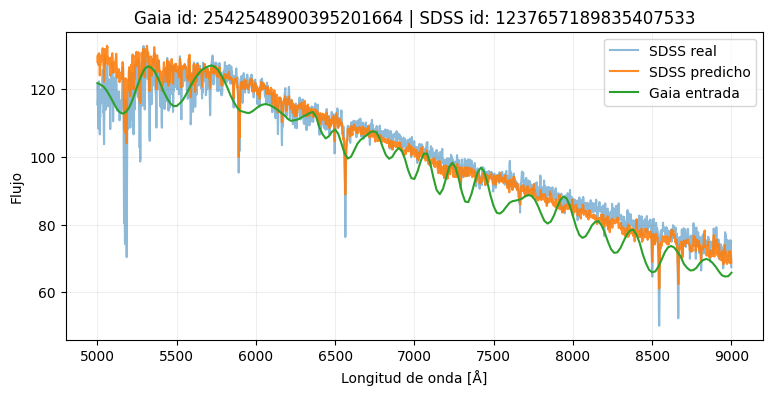

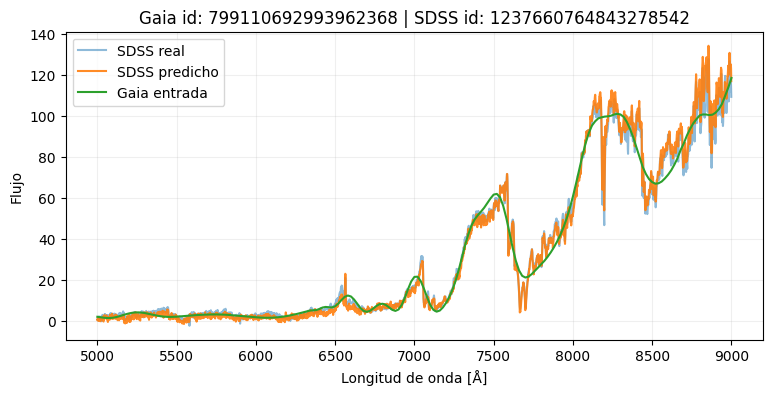

128/128 ━━━━━━━━━━━━━━━━━━━━ 22s 172ms/step - loss: 0.0046 - mae: 0.0505 - mse: 0.0126


In [38]:
plot_prediction_example(
    245,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_birnn_attention,
    y_id_test,
    X_test,
    X_id_test
)

plot_prediction_example(
    10,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_birnn_attention,
    y_id_test,
    X_test,
    X_id_test
)

test_loss, test_mae, test_mse = model_birnn_attention.evaluate(
    X_test_rnn,
    y_test_norm_median_spec,
    verbose=1
)

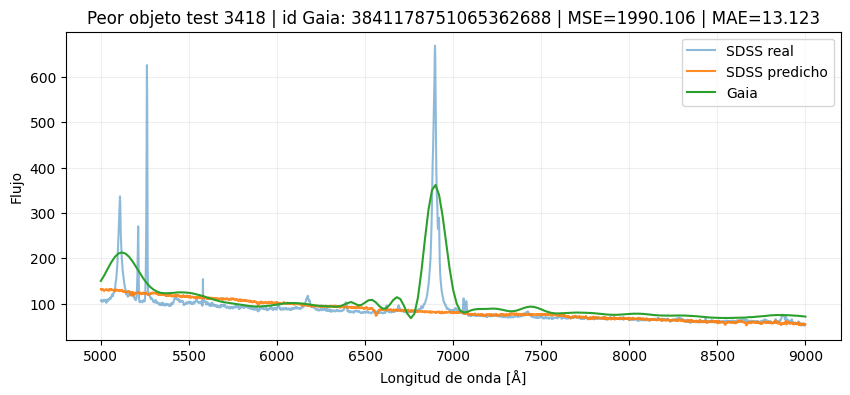

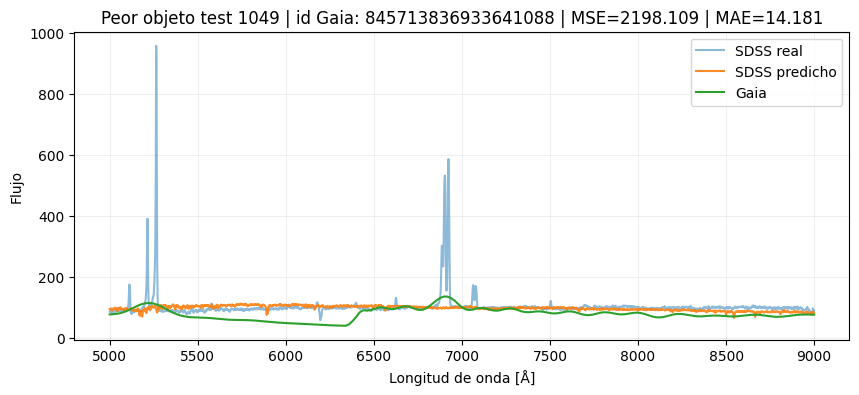

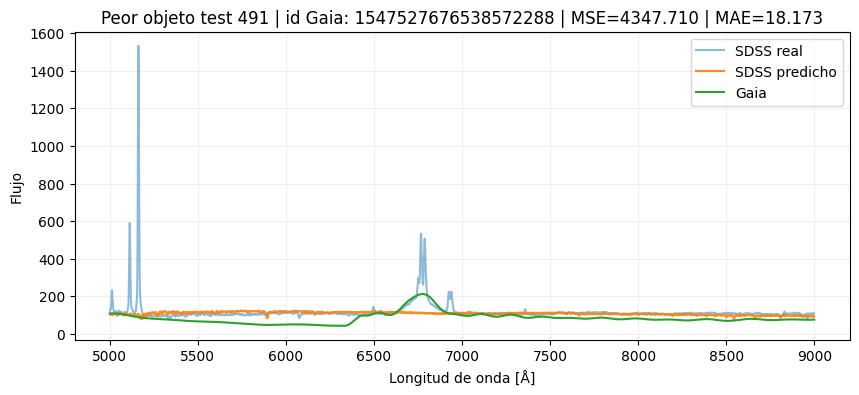

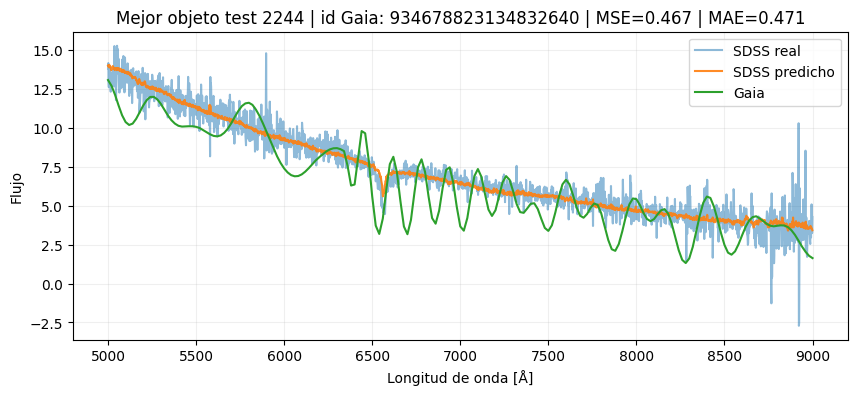

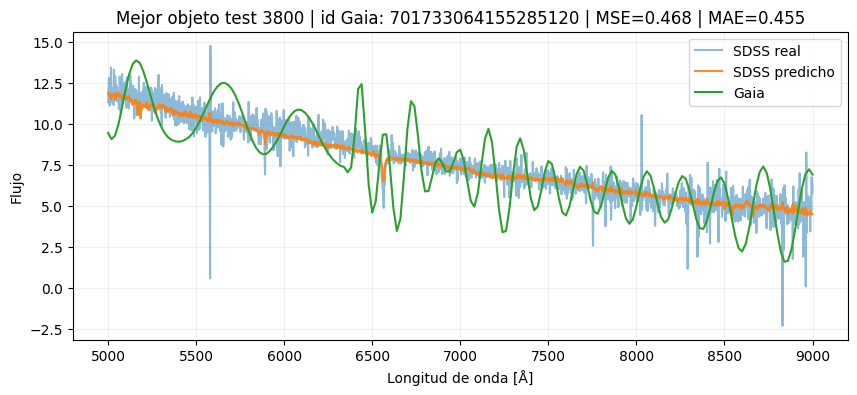

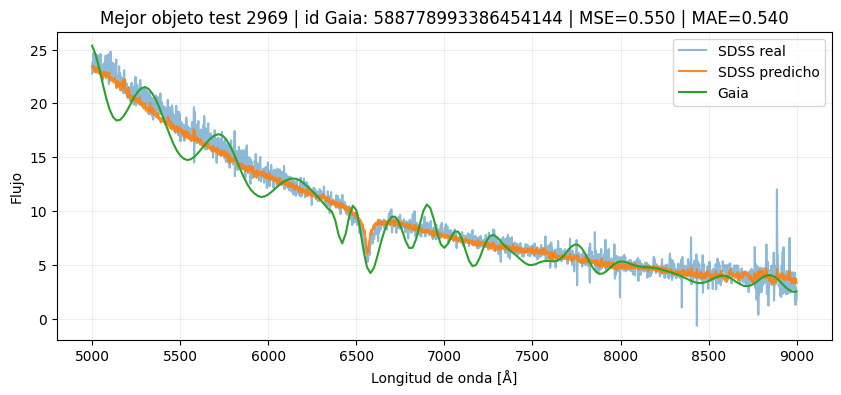

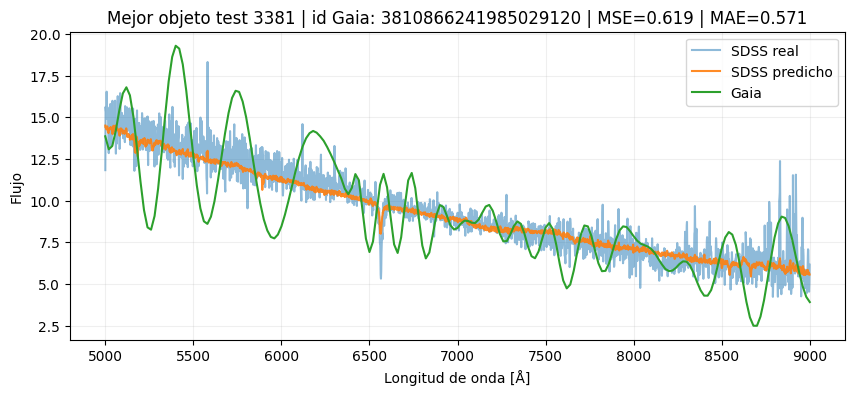

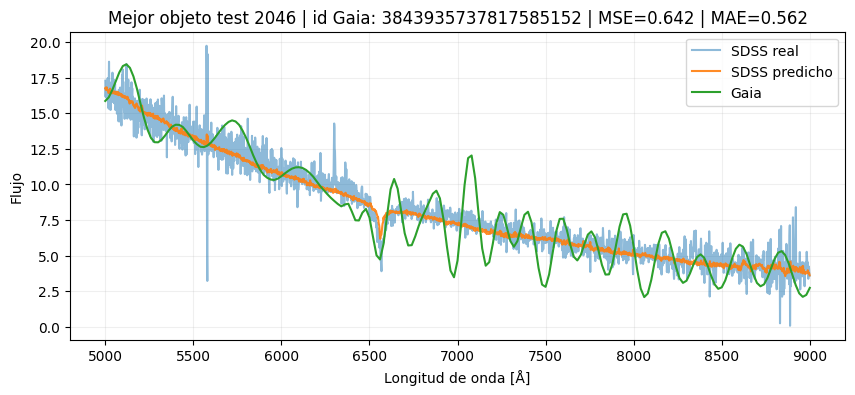

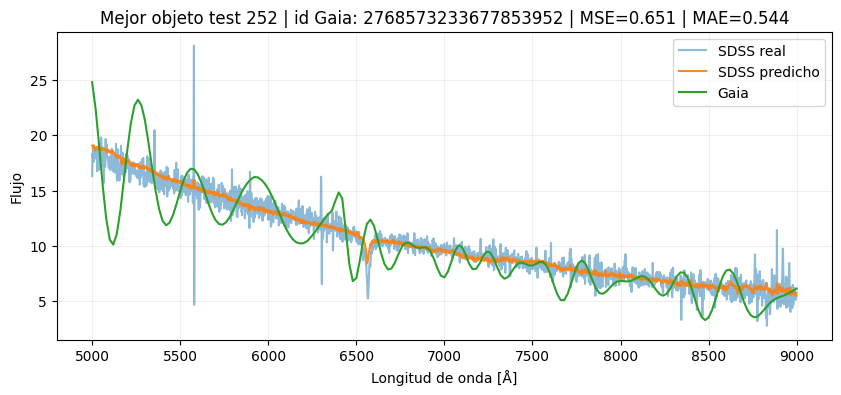

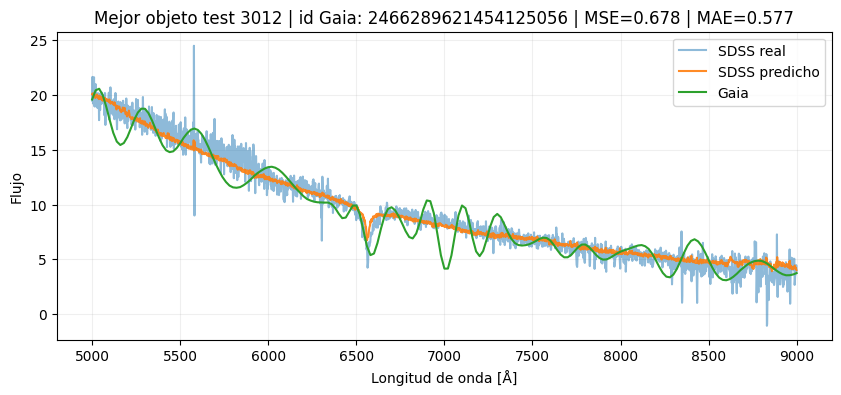

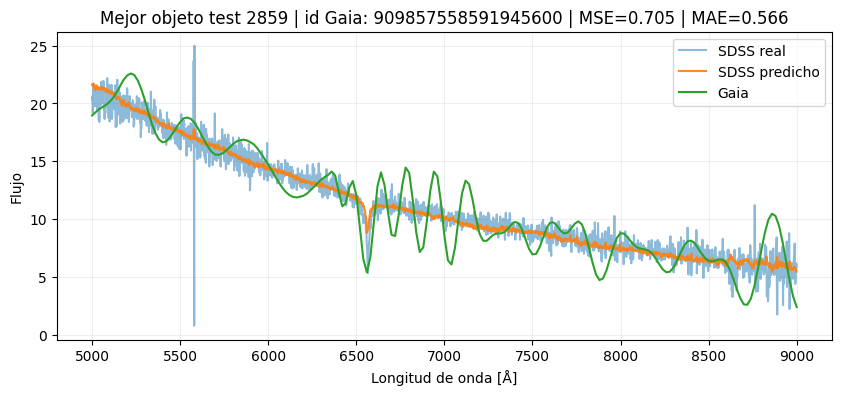

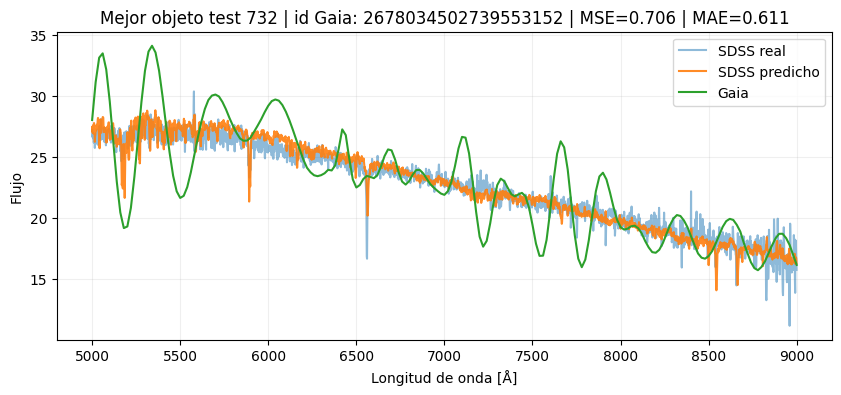

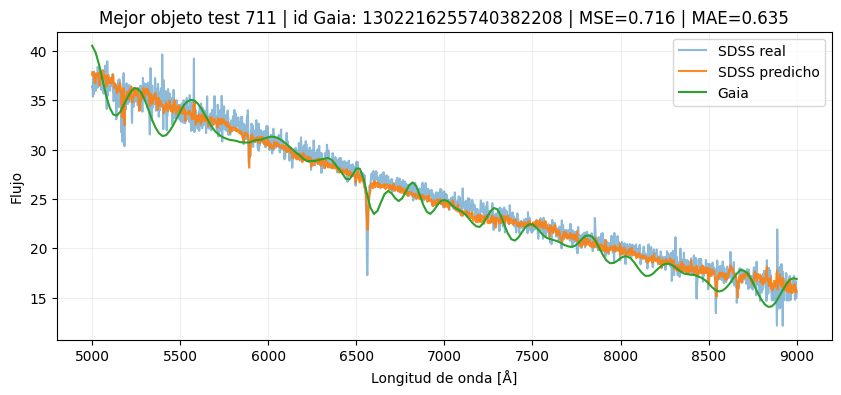

In [39]:
plot_worst_best_predictions(
    y_test,
    y_pred_birnn_attention,
    X_test,
    X_id_test,
    sdss_wavelength,
    gaia_wavelength,
    3
)

In [ ]:
import sys
from pathlib import Path

ISPEC_FUNCTIONS_DIR = Path(
    "../solution/models"
)

if str(ISPEC_FUNCTIONS_DIR) not in sys.path:
    sys.path.insert(0, str(ISPEC_FUNCTIONS_DIR))

# Importamos Funciones iSpec
from iSpec_functions import (
    load_ispec_resources,
    analyze_sample_real_vs_pred,
    analyze_ispec_errors
)

# Cargamos Resources
resources = load_ispec_resources()

from astropy.table import Table
# Cargamos la tabla de Gaia guardada en local
gaia_data_path = Path("../data/gaia_data.ecsv")

gaia_data_table = Table.read(
    gaia_data_path,
    format="ascii.ecsv"
)

# Pasamos a dataframe
gaia_data_df = gaia_data_table.to_pandas()

## BORRAR TODO
# Analizamos y devolvemos DF con valores ajustados a los espectros
results_df_attention = analyze_sample_real_vs_pred(   
    y_test,
    y_pred_birnn_attention,
    X_id_test,
    gaia_data_df,
    sdss_wavelength,
    resources,
    sample_size=250
)

In [ ]:
error_df_attention = analyze_ispec_errors(results_df_attention)

In [33]:
model_birnn_simple = models.Sequential([
    layers.Input(shape=(n_gaia, n_features)),

    layers.Bidirectional(layers.GRU(128, return_sequences=False)),

    layers.LayerNormalization(),

    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(n_sdss)
])

model_birnn_simple.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm=1.0),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_birnn_simple.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_4 (Bidirectional) │ (None, 256)            │       100,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_5           │ (None, 256)            │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_16 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_17 (LeakyReLU)      │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,589,866 (21.32 MB)

 Trainable params: 5,589,866 (21.32 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
history_birnn_simple = model_birnn_simple.fit(
    X_train_rnn,
    y_train_norm_median_spec,
    validation_data=(X_val_rnn, y_val_norm_median_spec),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop_earlier, reduce_lr_earlier],
    verbose=1
)

Epoch 1/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 324s 614ms/step - loss: 0.0665 - mae: 0.1977 - mse: 0.1521 - val_loss: 0.0061 - val_mae: 0.0642 - val_mse: 0.0175 - learning_rate: 1.0000e-04
Epoch 2/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 302s 589ms/step - loss: 0.0058 - mae: 0.0595 - mse: 0.0150 - val_loss: 0.0053 - val_mae: 0.0571 - val_mse: 0.0155 - learning_rate: 1.0000e-04
Epoch 3/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - loss: 0.0051 - mae: 0.0552 - mse: 0.0130
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
511/511 ━━━━━━━━━━━━━━━━━━━━ 269s 526ms/step - loss: 0.0051 - mae: 0.0552 - mse: 0.0130 - val_loss: 0.0053 - val_mae: 0.0578 - val_mse: 0.0155 - learning_rate: 1.0000e-04
Epoch 4/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 253s 495ms/step - loss: 0.0047 - mae: 0.0521 - mse: 0.0120 - val_loss: 0.0047 - val_mae: 0.0521 - val_mse: 0.0143 - learning_rate: 5.0000e-05
Epoch 5/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 600ms/step - loss: 0.0046 - mae: 0.0514 - mse: 0.0119
Epoch 5: Redu

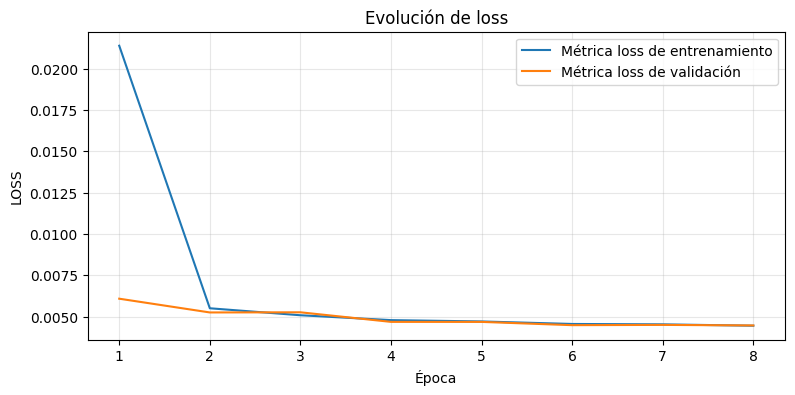

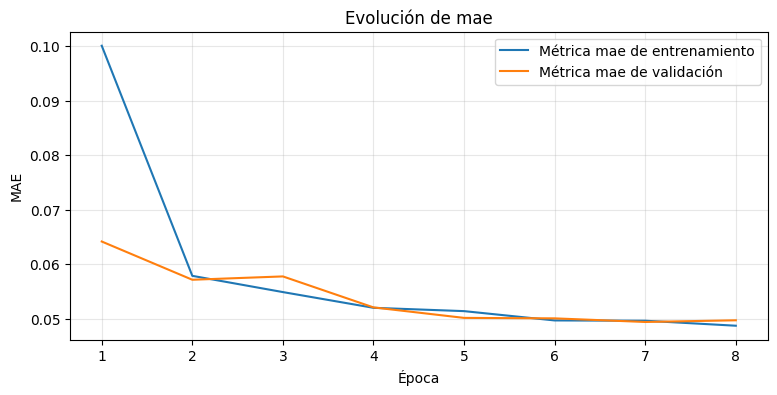

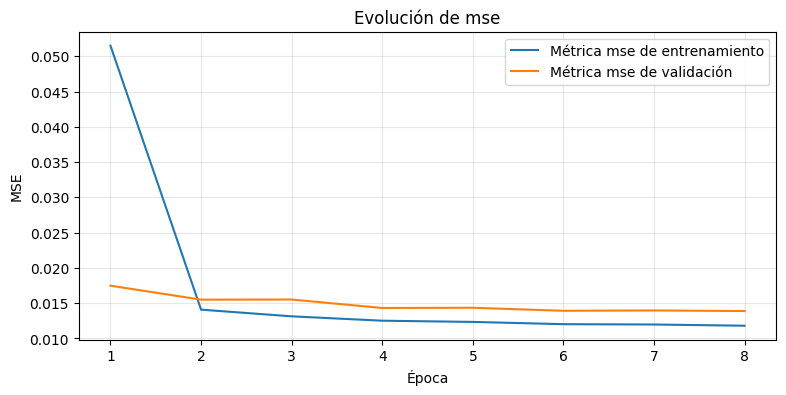

128/128 ━━━━━━━━━━━━━━━━━━━━ 24s 152ms/step


In [36]:
model_data_birnn_simple = history_birnn_simple.history
plot_training_metrics(model_data_birnn_simple)

# Predecimos sobre el conjunto de test
y_pred_birnn_simple_norm = model_birnn_simple.predict(X_test_rnn)
y_pred_birnn_simple = y_pred_birnn_simple_norm * y_scale_test

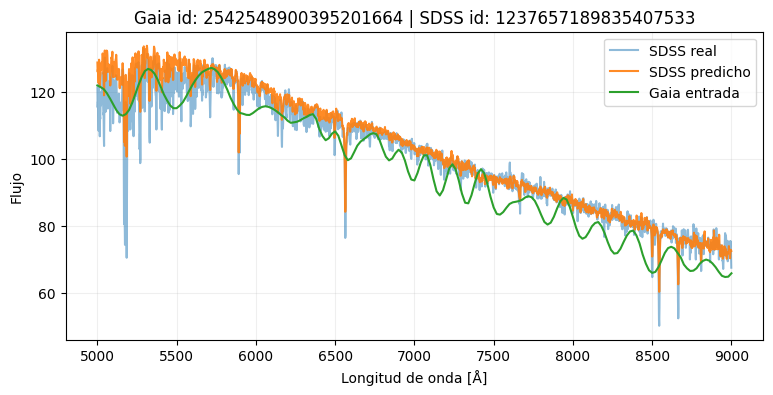

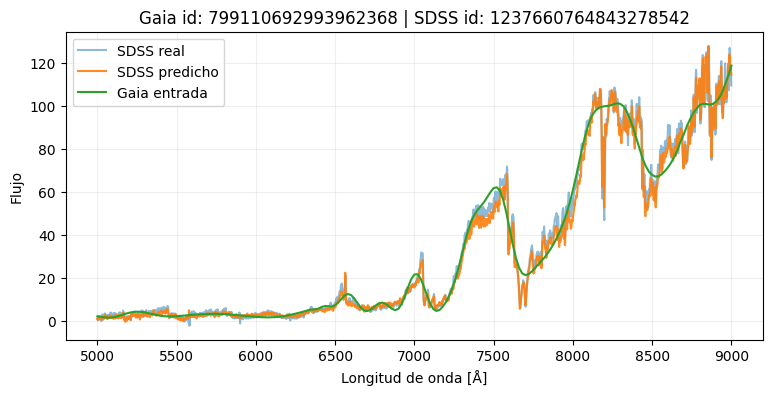

128/128 ━━━━━━━━━━━━━━━━━━━━ 14s 108ms/step - loss: 0.0045 - mae: 0.0503 - mse: 0.0124


In [37]:
plot_prediction_example(
    245,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_birnn_simple,
    y_id_test,
    X_test,
    X_id_test
)

plot_prediction_example(
    10,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_birnn_simple,
    y_id_test,
    X_test,
    X_id_test
)

test_loss, test_mae, test_mse = model_birnn_simple.evaluate(
    X_test_rnn,
    y_test_norm_median_spec,
    verbose=1
)

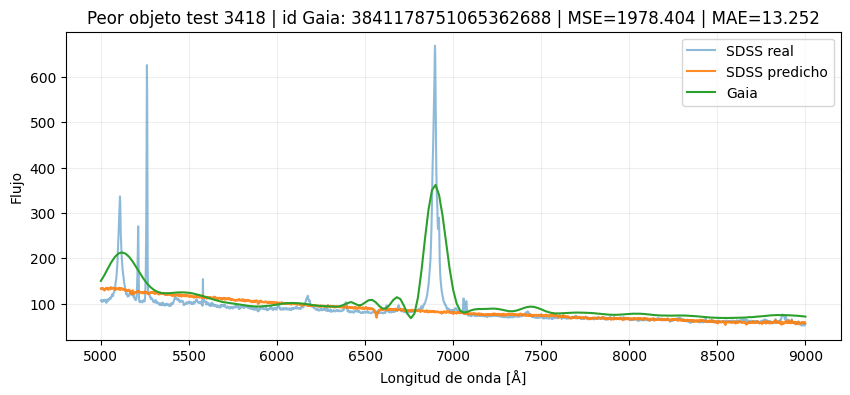

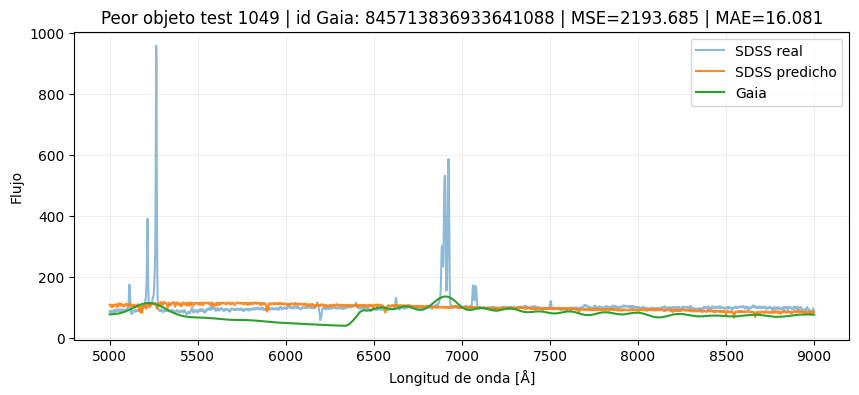

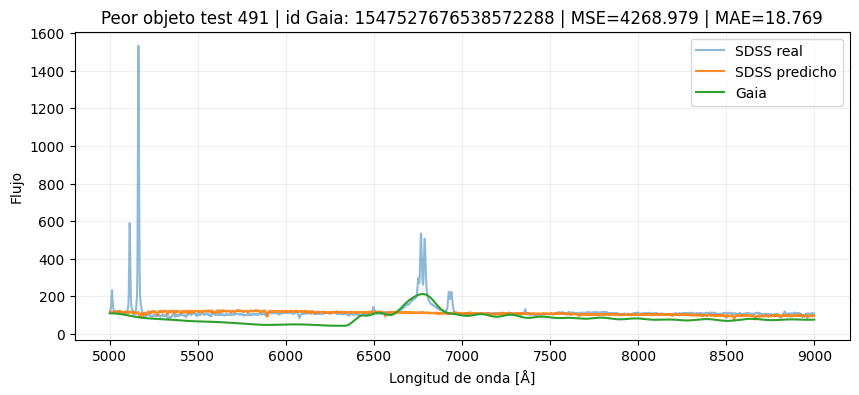

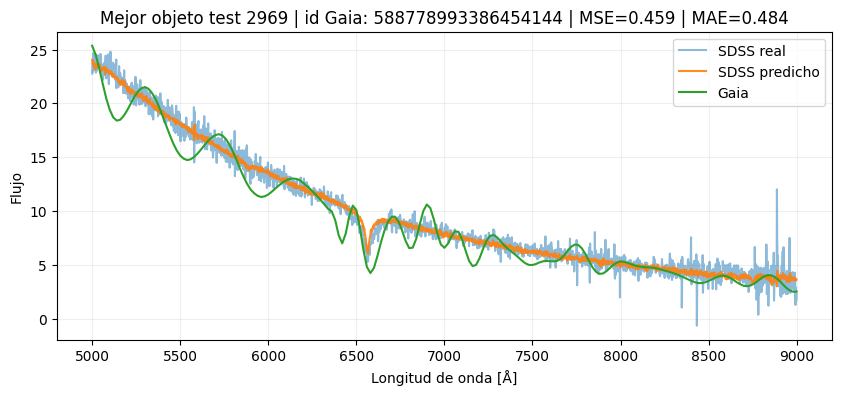

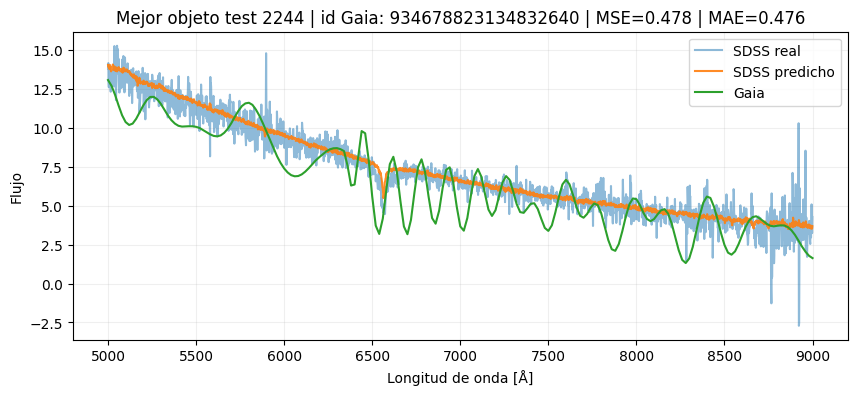

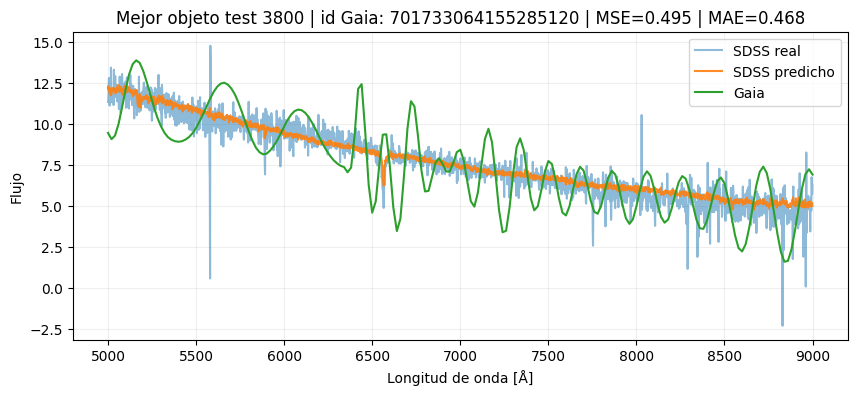

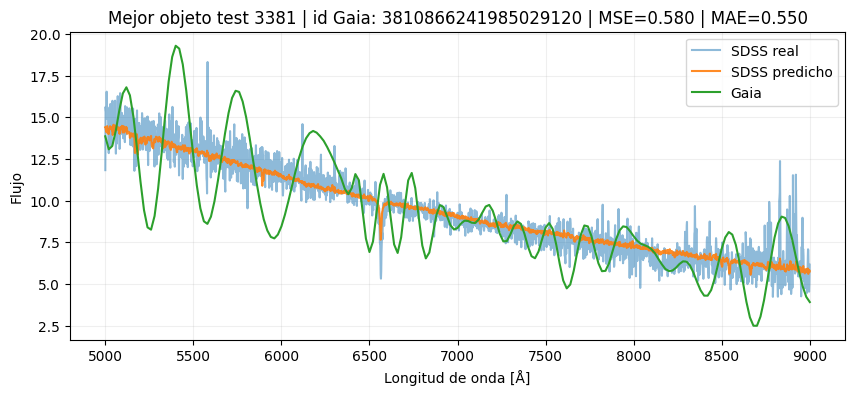

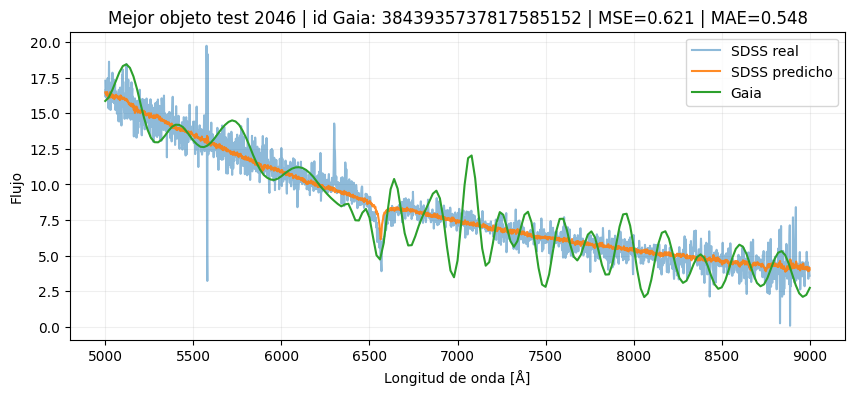

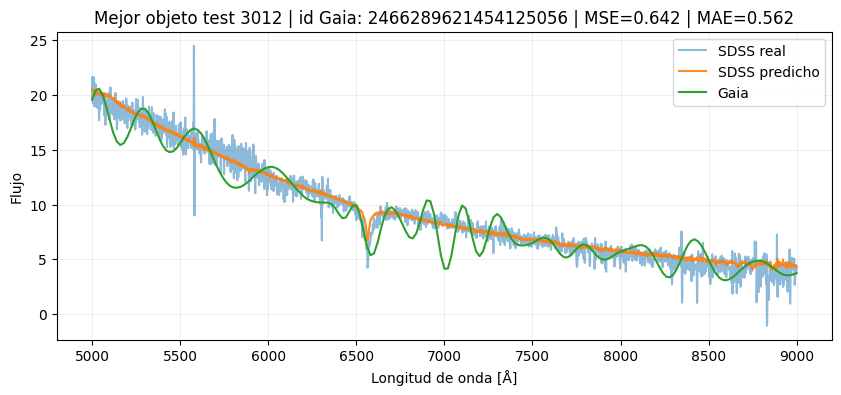

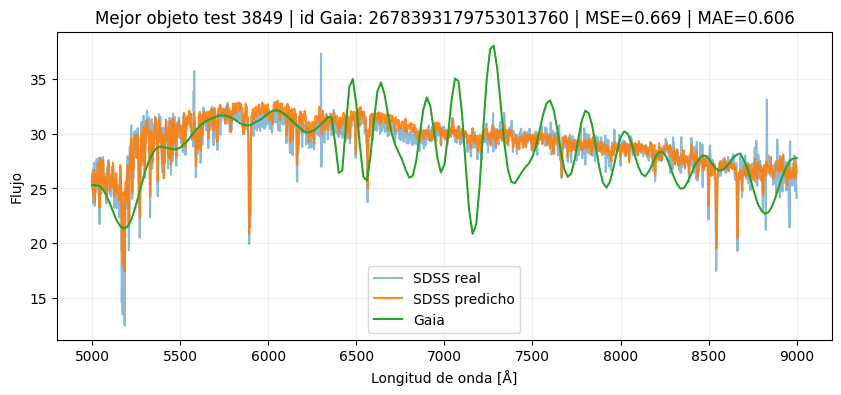

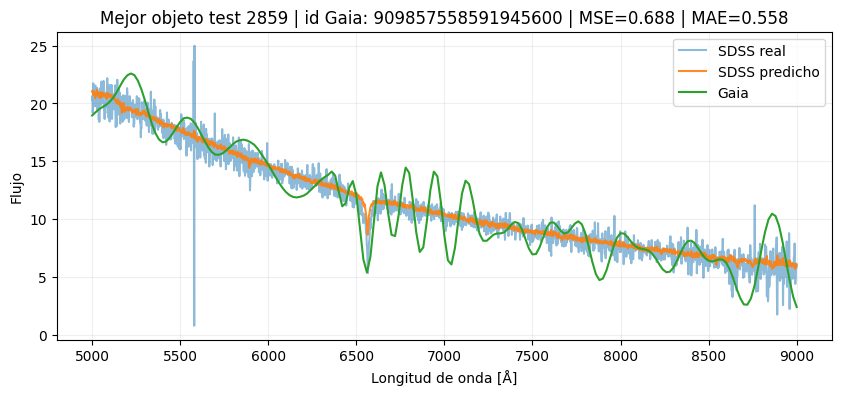

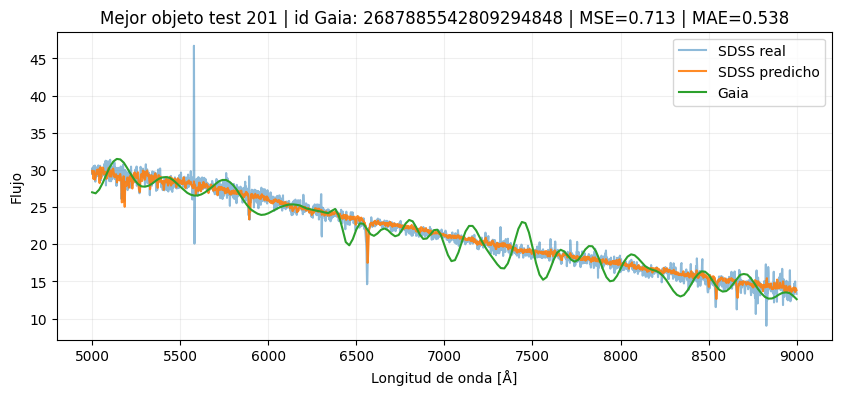

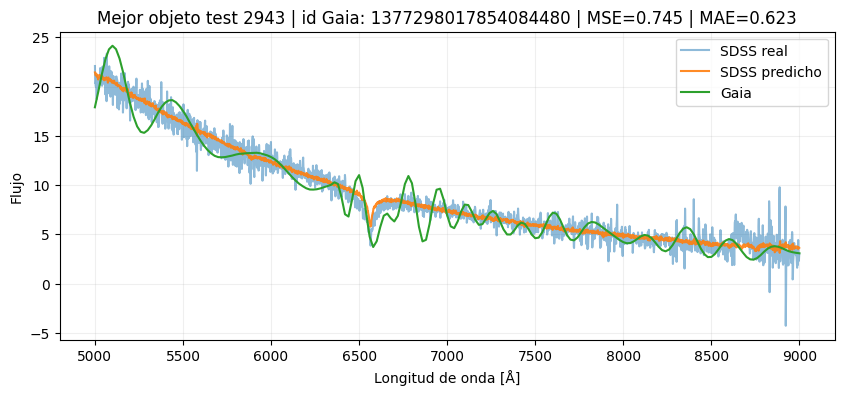

In [40]:
plot_worst_best_predictions(
    y_test,
    y_pred_birnn_simple,
    X_test,
    X_id_test,
    sdss_wavelength,
    gaia_wavelength,
    3
)

In [ ]:
# Analizamos y devolvemos DF con valores ajustados a los espectros
results_df_simple_birnn = analyze_sample_real_vs_pred(   
    y_test,
    y_pred_birnn_simple,
    X_id_test,
    gaia_data_df,
    sdss_wavelength,
    resources,
    sample_size=250
)

In [ ]:
error_df_simple_birnn = analyze_ispec_errors(results_df_simple_birnn)

In [11]:
n_gaia = X_train_rnn.shape[1]
n_features = X_train_rnn.shape[2]
n_sdss = y_train_norm_median_spec.shape[1]


model_birnn_simple_2 = models.Sequential([
    layers.Input(shape=(n_gaia, n_features)),

    layers.Bidirectional(layers.GRU(128, return_sequences=False)),

    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(n_sdss)
])

model_birnn_simple_2.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm=1.0),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_birnn_simple_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 256)            │       100,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,589,354 (21.32 MB)

 Trainable params: 5,589,354 (21.32 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
early_stop_earlier = EarlyStopping(
    monitor="val_loss",
    patience=2,
    min_delta=1e-4,
    restore_best_weights=True
)

reduce_lr_earlier = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-6,
    verbose=1
)

In [15]:
history_birnn_simple_2 = model_birnn_simple_2.fit(
    X_train_rnn,
    y_train_norm_median_spec,
    validation_data=(X_val_rnn, y_val_norm_median_spec),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop_earlier, reduce_lr_earlier],
    verbose=1
)

Epoch 1/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 181s 348ms/step - loss: 0.1064 - mae: 0.2875 - mse: 0.2376 - val_loss: 0.0069 - val_mae: 0.0731 - val_mse: 0.0192 - learning_rate: 1.0000e-04
Epoch 2/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 176s 344ms/step - loss: 0.0059 - mae: 0.0613 - mse: 0.0153 - val_loss: 0.0053 - val_mae: 0.0585 - val_mse: 0.0156 - learning_rate: 1.0000e-04
Epoch 3/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 179s 351ms/step - loss: 0.0051 - mae: 0.0553 - mse: 0.0130 - val_loss: 0.0050 - val_mae: 0.0554 - val_mse: 0.0150 - learning_rate: 1.0000e-04
Epoch 4/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 233s 456ms/step - loss: 0.0050 - mae: 0.0542 - mse: 0.0131 - val_loss: 0.0049 - val_mae: 0.0537 - val_mse: 0.0147 - learning_rate: 1.0000e-04
Epoch 5/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - loss: 0.0049 - mae: 0.0534 - mse: 0.0125
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
511/511 ━━━━━━━━━━━━━━━━━━━━ 205s 402ms/step - loss: 0.0049 - mae: 0.0534 - mse: 0.0125 - val_loss:

In [16]:
test_results_birnn_simple_2 = model_birnn_simple_2.evaluate(
    X_test_rnn,
    y_test_norm_median_spec,
    verbose=1
)

128/128 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - loss: 0.0048 - mae: 0.0533 - mse: 0.0129


In [17]:
y_pred_norm_birnn_simple_2= model_birnn_simple_2.predict(X_test_norm_median_spec)
y_pred_spec_birnn_simple_2= y_pred_norm_birnn_simple_2* y_scale_test

128/128 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step


In [18]:
results_df_birnn_simple_2 = analyze_sample_real_vs_pred(   
    y_test,
    y_pred_spec_birnn_simple_2,
    X_id_test,
    gaia_data_df,
    sdss_wavelength,
    resources,
    sample_size=250
)

Espectros analizados:   0%|          | 0/250 [00:00<?, ?cuerpos estelares/s]

Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE




Only LTE



Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE


[2026-08-26 02:31:50,219] [WARNING] [atmospheres:_interpolate:114]: Target point '3500.0 2.6911155921887264 -4.559396401646393 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-08-26 02:31:53,254] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.
[2026-08-26 02:32:05,662] [WARNING] [atmospheres:_interpolate:114]: Target point '3500.0 2.9241712653553704 -4.433403594384137 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-08-26 02:32:08,687] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.
[2026-08-26 02:32:21,760] [WARNING] [atmospheres:_interpolate:114]: Target point '3538.718101860612 2.1204109244531257 -4.114757058193999 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-2
. . . now exiting to system . . .
[2026-08-2

Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE

[2026-08-26 04:10:55,319] [WARNING] [atmospheres:_interpolate:114]: Target point '6898.861174734105 4.405698264094979 -5.5 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-08-26 04:10:58,351] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.


Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE


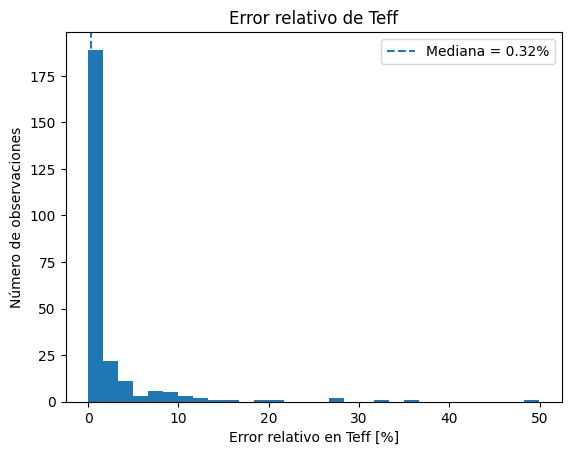

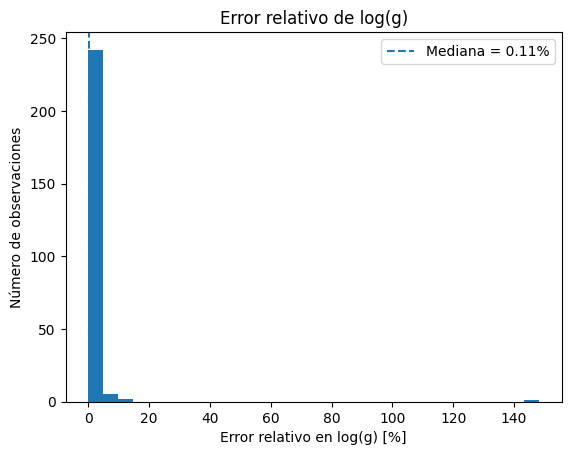

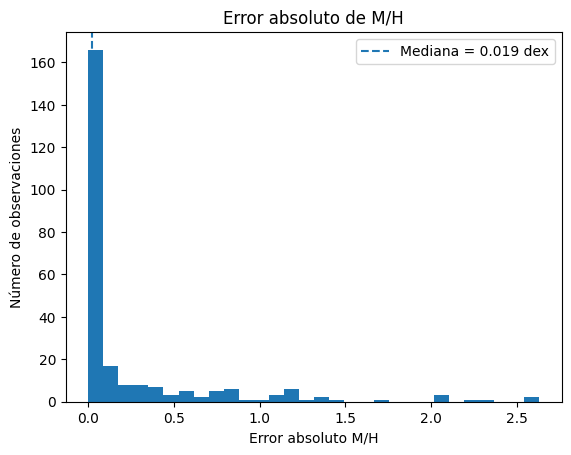

In [34]:
error_birnn_simple_2 = analyze_ispec_errors(results_df_birnn_simple_2)

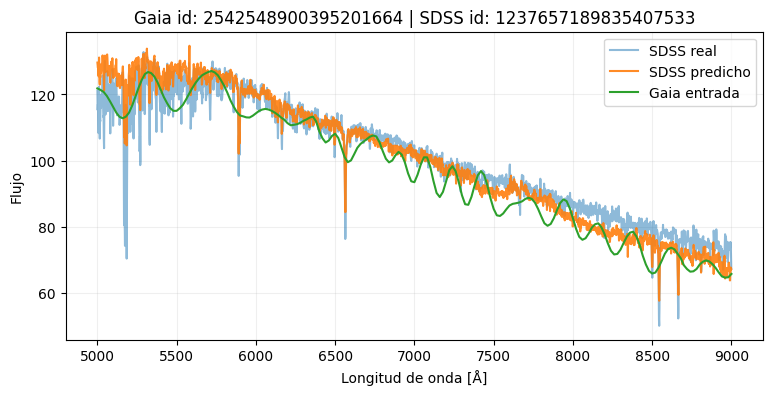

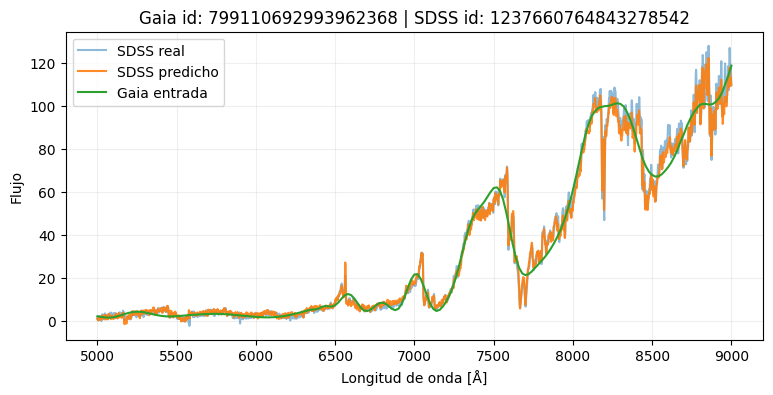

In [40]:
plot_prediction_example(
    245,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_spec_birnn_simple_2,
    y_id_test,
    X_test,
    X_id_test
)

plot_prediction_example(
    10,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_spec_birnn_simple_2,
    y_id_test,
    X_test,
    X_id_test
)

In [21]:
inputs = layers.Input(shape=(n_gaia, n_features))

x = layers.Bidirectional(layers.GRU(128,return_sequences=True))(inputs)
x = layers.Bidirectional(layers.GRU(64,return_sequences=True))(x)

# Aplicamos Atención sobre todos los puntos del espectro
x = AttentionPooling()(x)

# Parte densa que ya hemos comprobado que funciona bien
x = layers.Dense(512)(x)
x = layers.LeakyReLU(negative_slope=0.01)(x)

x = layers.Dense(1024, activation="elu")(x)

x = layers.Dense(1024)(x)
x = layers.LeakyReLU(negative_slope=0.01)(x)

x = layers.Dense(1024, activation="elu")(x)

outputs = layers.Dense(n_sdss)(x)

model_birnn_attention_2 = models.Model(inputs, outputs)

model_birnn_attention_2.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm=1.0),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_birnn_attention_2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 201, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 201, 256)       │       100,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 201, 128)       │       123,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_pooling               │ (None, 128)            │           129 │
│ (AttentionPooling)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,647,595 (21.54 MB)

 Trainable params: 5,647,595 (21.54 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history_birnn_attention_2 = model_birnn_attention_2.fit(
    X_train_rnn,
    y_train_norm_median_spec,
    validation_data=(X_val_rnn, y_val_norm_median_spec),
    epochs=15,
    batch_size=64,
    callbacks=[early_stop_earlier, reduce_lr_earlier],
    verbose=1
)

Epoch 1/15
511/511 ━━━━━━━━━━━━━━━━━━━━ 228s 438ms/step - loss: 0.1301 - mae: 0.3502 - mse: 0.2901 - val_loss: 0.0509 - val_mae: 0.2030 - val_mse: 0.1254 - learning_rate: 1.0000e-04
Epoch 2/15
511/511 ━━━━━━━━━━━━━━━━━━━━ 259s 507ms/step - loss: 0.0522 - mae: 0.2094 - mse: 0.1241 - val_loss: 0.0508 - val_mae: 0.1995 - val_mse: 0.1258 - learning_rate: 1.0000e-04
Epoch 3/15
511/511 ━━━━━━━━━━━━━━━━━━━━ 264s 517ms/step - loss: 0.0319 - mae: 0.1476 - mse: 0.0796 - val_loss: 0.0052 - val_mae: 0.0534 - val_mse: 0.0158 - learning_rate: 1.0000e-04
Epoch 4/15
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 502ms/step - loss: 0.0053 - mae: 0.0565 - mse: 0.0138
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
511/511 ━━━━━━━━━━━━━━━━━━━━ 267s 522ms/step - loss: 0.0053 - mae: 0.0565 - mse: 0.0138 - val_loss: 0.0055 - val_mae: 0.0594 - val_mse: 0.0159 - learning_rate: 1.0000e-04
Epoch 5/15
511/511 ━━━━━━━━━━━━━━━━━━━━ 303s 593ms/step - loss: 0.0048 - mae: 0.0522 - mse: 0.0130 - val_loss:

In [23]:
test_results_rnn_attention_2 = model_birnn_attention_2.evaluate(
    X_test_rnn,
    y_test_norm_median_spec,
    verbose=1
)

128/128 ━━━━━━━━━━━━━━━━━━━━ 13s 100ms/step - loss: 0.0046 - mae: 0.0506 - mse: 0.0127


In [24]:
y_pred_norm_birnn_attention_2= model_birnn_attention_2.predict(X_test_norm_median_spec)
y_pred_spec_birnn_attention_2= y_pred_norm_birnn_attention_2* y_scale_test

128/128 ━━━━━━━━━━━━━━━━━━━━ 13s 95ms/step


In [25]:
results_df_birnn_attention_2 = analyze_sample_real_vs_pred(   
    y_test,
    y_pred_spec_birnn_attention_2,
    X_id_test,
    gaia_data_df,
    sdss_wavelength,
    resources,
    sample_size=250
)

Espectros analizados:   0%|          | 0/250 [00:00<?, ?cuerpos estelares/s]

Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE




Only LTE



Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE


[2026-08-26 15:50:17,926] [WARNING] [atmospheres:_interpolate:114]: Target point '3500.0 2.6911155921887264 -4.559396401646393 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-08-26 15:50:21,968] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.
[2026-08-26 15:50:40,492] [WARNING] [atmospheres:_interpolate:114]: Target point '3500.0 2.9241712653553704 -4.433403594384137 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-08-26 15:50:44,531] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.
[2026-08-26 15:51:02,916] [WARNING] [atmospheres:_interpolate:114]: Target point '3538.718101860612 2.1204109244531257 -4.114757058193999 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-2
. . . now exiting to system . . .
[2026-08-2

Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE

[2026-08-26 18:00:51,621] [WARNING] [atmospheres:_interpolate:114]: Target point '6885.6399025060755 4.3976364084314765 -5.5 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-08-26 18:00:54,653] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.


Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE


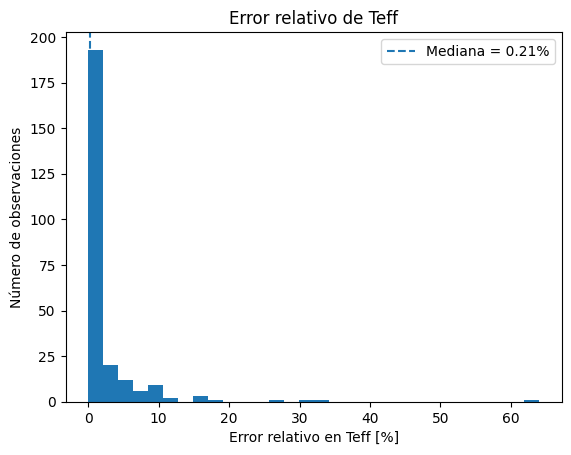

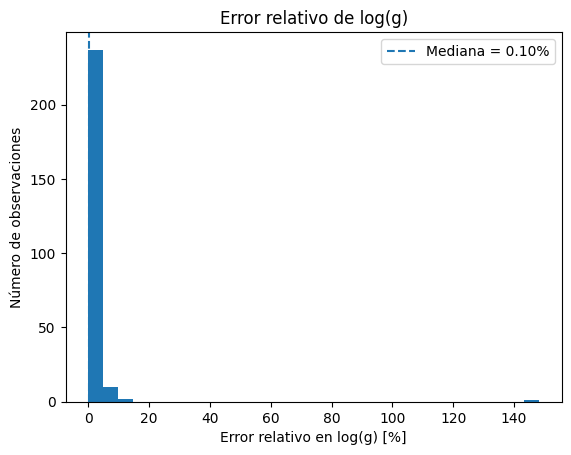

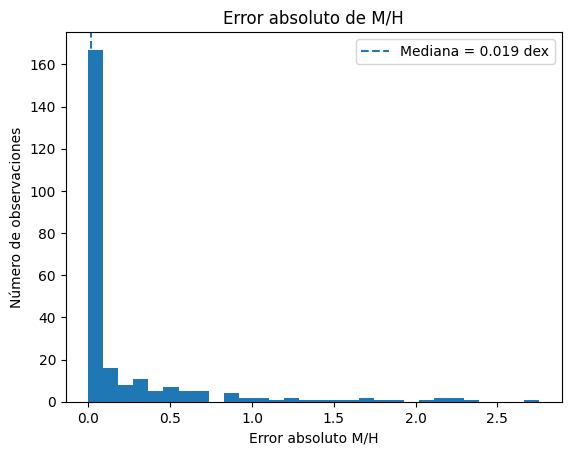

In [35]:
error_birnn_attention_2 = analyze_ispec_errors(results_df_birnn_attention_2)

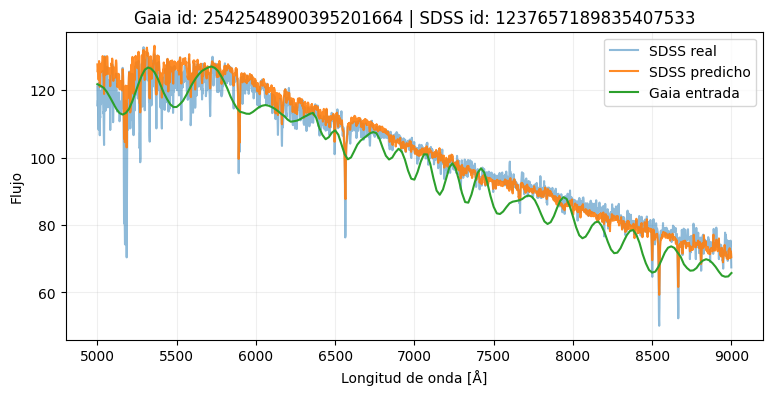

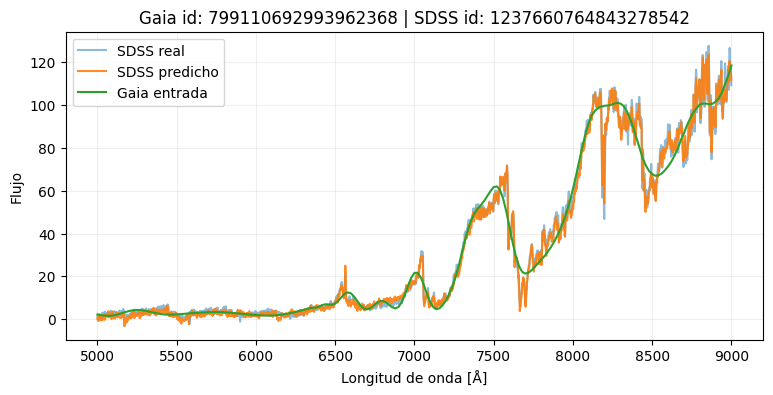

In [41]:
plot_prediction_example(
    245,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_spec_birnn_attention_2,
    y_id_test,
    X_test,
    X_id_test
)

plot_prediction_example(
    10,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_spec_birnn_attention_2,
    y_id_test,
    X_test,
    X_id_test
)

In [36]:
predictions_path = Path("../data/predictions/predicciones_modelos_BIRNN_3.npz")
predictions_path.parent.mkdir(parents=True, exist_ok=True)

np.savez_compressed(
    predictions_path,
    
    # Predicciones de los modelos testeados
    #y_pred_birnn_attention = y_pred_birnn_attention,
   # y_pred_birnn_simple = y_pred_birnn_simple,
    #y_pred_spec_std = y_pred_spec,
  #  y_pred_spec_birnn_attention_2 = y_pred_spec_birnn_attention_2,
  #  y_pred_spec_birnn_simple_2 = y_pred_spec_birnn_simple_2
  y_pred_spec_small=y_pred_spec_small
)

In [37]:
from pathlib import Path

ispec_path = Path("../data/predictions/ispec_small.csv")
ispec_path.parent.mkdir(parents=True, exist_ok=True)

results_df_small.to_csv(
    ispec_path,
    index=False
)

ispec_path = Path("../data/predictions/ispec_attention.csv")
ispec_path.parent.mkdir(parents=True, exist_ok=True)

results_df_birnn_attention_2.to_csv(
    ispec_path,
    index=False
)

ispec_path = Path("../data/predictions/ispec_simple.csv")
ispec_path.parent.mkdir(parents=True, exist_ok=True)

results_df_birnn_simple_2.to_csv(
    ispec_path,
    index=False
)